how is the db file structured? open 1 as an example to check

In [ ]:
import sqlite3
import pandas as pd
from collections import defaultdict
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import networkx as nx 

### Plotting

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns

plt.style.use('ggplot')

rcParams['font.family'] = 'sans-serif'
rcParams['font.style'] = 'normal'

rcParams['figure.facecolor'] = 'white'
rcParams['figure.dpi'] = 80

rcParams['savefig.bbox'] = 'tight'
rcParams['savefig.dpi'] = 300
rcParams['savefig.transparent'] = True

rcParams['axes.spines.right'] = False
rcParams['axes.spines.top'] = False
rcParams['axes.labelsize'] = 10
rcParams['axes.labelcolor'] = 'black'
rcParams['axes.edgecolor'] = 'black'
rcParams['axes.linewidth'] = 1
rcParams['axes.facecolor'] = 'white'

rcParams['legend.fontsize'] = 6

rcParams['xtick.color'] = 'black'
rcParams['ytick.color'] = 'black'
rcParams['xtick.major.width'] = 1
rcParams['ytick.major.width'] = 1
rcParams['xtick.major.size'] = 2
rcParams['ytick.major.size'] = 2
rcParams['xtick.labelsize'] = 8
rcParams['ytick.labelsize'] = 8

rcParams['lines.linewidth'] = 1
rcParams['lines.markersize'] = 5

rcParams['grid.color'] = 'white'
rcParams['grid.linewidth'] = 0.0

In [ ]:
conn = sqlite3.connect("experiments_recsys/BA_F_0/database_server.db")

# Get all table names
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables = tables['name'].tolist()

# Function to print schema of a table
def print_table_schema(table_name):
    print(f"\nTable: {table_name}")
    schema = pd.read_sql_query(f"PRAGMA table_info({table_name});", conn)
    schema = schema.rename(columns={
        'cid': 'Column ID',
        'name': 'Column Name',
        'type': 'Data Type',
        'notnull': 'Not Null',
        'dflt_value': 'Default Value',
        'pk': 'Primary Key'
    })
    print(schema.to_string(index=False))

# Iterate over all tables and print their schema
for table in tables:
    print_table_schema(table)

# Close connection
conn.close()



Table: sqlite_sequence
 Column ID Column Name Data Type  Not Null Default Value  Primary Key
         0        name                   0          None            0
         1         seq                   0          None            0

Table: hashtags
 Column ID Column Name Data Type  Not Null Default Value  Primary Key
         0     hashtag      TEXT         1          None            0
         1          id   INTEGER         0          None            1

Table: post_hashtags
 Column ID Column Name Data Type  Not Null Default Value  Primary Key
         0     post_id   INTEGER         0          None            0
         1  hashtag_id   INTEGER         0          None            0
         2          id   INTEGER         1          None            1

Table: mentions
 Column ID Column Name Data Type  Not Null Default Value  Primary Key
         0          id   INTEGER         0           NaN            1
         1     user_id       INT         0           NaN            0
         2

# Recommendations

In [61]:
conn = sqlite3.connect("experiments_recsys/BA_F_0/database_server.db")
table_name = "recommendations"
recommendations = pd.read_sql_query(f"SELECT * FROM {table_name};", conn)
recommendations.head()

,id,user_id,post_ids,round
0,1,831,1,1
1,2,61,2|1,1
2,3,61,2|1,1
3,4,61,2|1,1
4,5,116,6|5|4|3,1


In [62]:
# Basic info
print(recommendations.info())  # shows types, non-null counts

# Summary statistics for numeric columns
print(recommendations.describe())

# Count unique values per column
print(recommendations.nunique())

<class 'pandas.DataFrame'>
RangeIndex: 79185 entries, 0 to 79184
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        79185 non-null  int64
 1   user_id   79185 non-null  int64
 2   post_ids  79185 non-null  str  
 3   round     79185 non-null  int64
dtypes: int64(3), str(1)
memory usage: 2.4 MB
None
                id       user_id         round
count  79185.00000  79185.000000  79185.000000
mean   39593.00000    505.806327    721.216885
std    22858.88487    296.451188    414.303874
min        1.00000      2.000000      1.000000
25%    19797.00000    235.000000    363.000000
50%    39593.00000    515.000000    718.000000
75%    59389.00000    767.000000   1078.000000
max    79185.00000   1001.000000   1440.000000
id          79185
user_id      1000
post_ids    29701
round        1440
dtype: int64


In [63]:
print((recommendations.post_ids.unique()))

<StringArray>
[                                                          '1',
                                                         '2|1',
                                                     '6|5|4|3',
                                                    '10|9|8|7',
                                                  '12|11|10|9',
                                        '10|9|8|7|17|16|15|14',
                                                 '18|17|16|15',
                                                 '21|20|19|18',
                                                 '26|25|24|23',
                                                 '27|26|25|24',
 ...
 '90989|90988|90987|90889|90888|90887|91162|91161|91160|91159',
 '90477|90476|90475|90409|90408|90182|91167|91166|91165|91164',
 '91066|91065|90651|90650|90649|90539|91173|91172|91171|91170',
                   '90379|90378|90377|91176|91175|91174|91173',
 '91051|91050|91049|91048|91047|91046|91178|91177|91176|91175',
             '90989|9

In [64]:
recommendations['post_ids_list'] = recommendations['post_ids'].apply(lambda x: [int(i) for i in x.split('|')])

In [65]:
recommendations.head()

,id,user_id,post_ids,round,post_ids_list
0,1,831,1,1,[1]
1,2,61,2|1,1,"[2, 1]"
2,3,61,2|1,1,"[2, 1]"
3,4,61,2|1,1,"[2, 1]"
4,5,116,6|5|4|3,1,"[6, 5, 4, 3]"


Quanti post vengono raccomandati ogni ora?

In [66]:
recommendations = recommendations.explode('post_ids_list')
recs_per_round = recommendations.groupby('round')['post_ids_list'].transform('nunique').reset_index(name='num_recs')
recs_per_round.head()

,index,num_recs
0,0,48
1,1,48
2,1,48
3,2,48
4,2,48


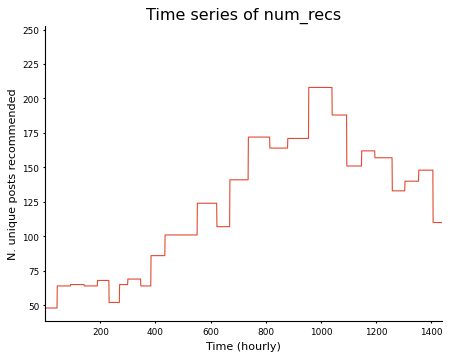

In [80]:
plt.plot(recs_per_round["index"], recs_per_round["num_recs"])
plt.xlabel("Time (hourly)")
plt.ylabel("N. unique posts recommended")
plt.title("Time series of num_recs")
plt.xlim(1, 1440)  # optional, if you want fixed bounds
plt.show()

# Users + Networks

In [9]:
conn = sqlite3.connect("experiments_recsys/BA_F_0/database_server.db")
table_name = "user_mgmt"
users = pd.read_sql_query(f"SELECT * FROM {table_name};", conn)
users.head()

,id,username,email,password,user_type,leaning,age,oe,co,ex,...,frecsys_type,round_actions,gender,nationality,toxicity,is_page,left_on,daily_activity_level,profession,activity_profile
0,1,Admin,admin@y-not.social,pbkdf2:sha256:1000000$p5aw8n4lKUZ33ZRE$26594a3...,user,none,0,NaN,NaN,NaN,...,default,3,NaN,NaN,none,0,None,1,NaN,NaN
1,2,MichaelChambers,MichaelChambers@ysocial.it,MichaelChambers,,democrat,48,consistent/cautious,efficient/organized,outgoing/energetic,...,FollowRecSys,2,male,American,none,0,None,1,Accountant,Always On
2,3,MarkLee,MarkLee@ysocial.it,MarkLee,,democrat,23,consistent/cautious,efficient/organized,outgoing/energetic,...,FollowRecSys,4,male,American,none,0,None,3,Postal Worker,Always On
3,4,ToddWells,ToddWells@ysocial.it,ToddWells,,democrat,22,consistent/cautious,efficient/organized,solitary/reserved,...,FollowRecSys,10,male,American,none,0,None,4,Bank Teller,Always On
4,5,JasonFerrell,JasonFerrell@ysocial.it,JasonFerrell,,democrat,19,consistent/cautious,efficient/organized,outgoing/energetic,...,FollowRecSys,5,male,American,none,0,None,1,Accountant,Always On


In [10]:
# --- Load edge list ---
edges = pd.read_csv("experiments_recsys/BA_F_0/cl6_network.csv", header=None, names=['source', 'target'], dtype=str)

# assume columns like: source, target with usernames
print(edges.head())

# --- Load users table ---
conn = sqlite3.connect("experiments_recsys/BA_F_0/database_server.db")
users = pd.read_sql_query("SELECT * FROM user_mgmt;", conn)

print(users.head())

            source           target
0  MichaelChambers          MarkLee
1          MarkLee  MichaelChambers
2  MichaelChambers        ToddWells
3        ToddWells  MichaelChambers
4  MichaelChambers     JasonFerrell
   id         username                       email  \
0   1            Admin          admin@y-not.social   
1   2  MichaelChambers  MichaelChambers@ysocial.it   
2   3          MarkLee          MarkLee@ysocial.it   
3   4        ToddWells        ToddWells@ysocial.it   
4   5     JasonFerrell     JasonFerrell@ysocial.it   

                                            password user_type   leaning  age  \
0  pbkdf2:sha256:1000000$p5aw8n4lKUZ33ZRE$26594a3...      user      none    0   
1                                    MichaelChambers            democrat   48   
2                                            MarkLee            democrat   23   
3                                          ToddWells            democrat   22   
4                                       JasonFerrell  

In [11]:
users

,id,username,email,password,user_type,leaning,age,oe,co,ex,...,frecsys_type,round_actions,gender,nationality,toxicity,is_page,left_on,daily_activity_level,profession,activity_profile
0,1,Admin,admin@y-not.social,pbkdf2:sha256:1000000$p5aw8n4lKUZ33ZRE$26594a3...,user,none,0,NaN,NaN,NaN,...,default,3,NaN,NaN,none,0,None,1,NaN,NaN
1,2,MichaelChambers,MichaelChambers@ysocial.it,MichaelChambers,,democrat,48,consistent/cautious,efficient/organized,outgoing/energetic,...,FollowRecSys,2,male,American,none,0,None,1,Accountant,Always On
2,3,MarkLee,MarkLee@ysocial.it,MarkLee,,democrat,23,consistent/cautious,efficient/organized,outgoing/energetic,...,FollowRecSys,4,male,American,none,0,None,3,Postal Worker,Always On
3,4,ToddWells,ToddWells@ysocial.it,ToddWells,,democrat,22,consistent/cautious,efficient/organized,solitary/reserved,...,FollowRecSys,10,male,American,none,0,None,4,Bank Teller,Always On
4,5,JasonFerrell,JasonFerrell@ysocial.it,JasonFerrell,,democrat,19,consistent/cautious,efficient/organized,outgoing/energetic,...,FollowRecSys,5,male,American,none,0,None,1,Accountant,Always On
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,997,NicholasMayer,NicholasMayer@ysocial.it,NicholasMayer,,democrat,47,consistent/cautious,extravagant/careless,solitary/reserved,...,FollowRecSys,8,male,American,none,0,None,1,Fisherman,Always On
997,998,TiffanyMartin,TiffanyMartin@ysocial.it,TiffanyMartin,,democrat,41,consistent/cautious,extravagant/careless,solitary/reserved,...,FollowRecSys,2,female,American,none,0,None,1,Soldier,Always On
998,999,BrianWolfe,BrianWolfe@ysocial.it,BrianWolfe,,democrat,40,consistent/cautious,efficient/organized,outgoing/energetic,...,FollowRecSys,9,male,American,none,0,None,4,Military Officer,Always On
999,1000,StaceyRussell,StaceyRussell@ysocial.it,StaceyRussell,,democrat,41,inventive/curious,efficient/organized,solitary/reserved,...,FollowRecSys,8,female,American,none,0,None,2,Gambler,Always On


In [12]:
username_to_id = dict(zip(users["username"], users["id"]))

edges["source_id"] = edges["source"].map(username_to_id)
edges["target_id"] = edges["target"].map(username_to_id)

# optional: drop edges with missing mappings
edges = edges.dropna(subset=["source_id", "target_id"])

In [13]:
edges

,source,target,source_id,target_id
0,MichaelChambers,MarkLee,2,3
1,MarkLee,MichaelChambers,3,2
2,MichaelChambers,ToddWells,2,4
3,ToddWells,MichaelChambers,4,2
4,MichaelChambers,JasonFerrell,2,5
...,...,...,...,...
9945,RachelLawson,JerryCampbell,989,967
9946,HeatherGuzman,NancyJohnson,968,976
9947,NancyJohnson,HeatherGuzman,976,968
9948,RonaldCortez,MatthewRodriguez,974,991


In [14]:
print(sorted(edges.source_id.unique()))
print(min(edges.source_id.unique()))
print(max(edges.source_id.unique()))
print(len(edges.source_id.unique()))

[np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73),

In [15]:
print(sorted(edges.target_id.unique()))
print(min(edges.target_id.unique()))
print(max(edges.target_id.unique()))
print(len(edges.target_id.unique()))

[np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(70), np.int64(71), np.int64(72), np.int64(73),

In [16]:
G = nx.from_pandas_edgelist(
    edges,
    source="source_id",
    target="target_id",
    create_using=nx.DiGraph()
)


In [17]:
id_to_username = dict(zip(users["id"], users["username"]))

nx.set_node_attributes(G, id_to_username, name="username")

In [18]:
G.nodes(data=True)

NodeDataView({2: {'username': 'MichaelChambers'}, 3: {'username': 'MarkLee'}, 4: {'username': 'ToddWells'}, 5: {'username': 'JasonFerrell'}, 6: {'username': 'JoshuaMckinney'}, 7: {'username': 'KennethChaney'}, 8: {'username': 'HeatherWhite'}, 9: {'username': 'StephanieKelly'}, 10: {'username': 'RebekahFoster'}, 13: {'username': 'WesleySimmons'}, 14: {'username': 'JacobClarke'}, 15: {'username': 'MichaelJohnson'}, 16: {'username': 'SamanthaStafford'}, 17: {'username': 'DavidBooth'}, 22: {'username': 'MichaelHester'}, 26: {'username': 'DarrenMccall'}, 31: {'username': 'StephenHughes'}, 37: {'username': 'PaulMoore'}, 42: {'username': 'BenjaminHoward'}, 48: {'username': 'LaurenBurns'}, 50: {'username': 'KennethDavis'}, 60: {'username': 'SaraRomero'}, 65: {'username': 'ChristopherManning'}, 77: {'username': 'AndreaGomez'}, 83: {'username': 'ChristopherClark'}, 87: {'username': 'JudithAnderson'}, 91: {'username': 'MirandaMontes'}, 100: {'username': 'MichelleMorrow'}, 101: {'username': 'Mr.Ma

In [19]:
deg = dict(G.degree())

degree_df = pd.DataFrame({
    "user_id": list(G.nodes()),
    "degree": [int(deg[n]/2) for n in G.nodes()],
})

# optional: add usernames for readability
degree_df["username"] = degree_df["user_id"].map(id_to_username)

print(degree_df.head())

   user_id  degree         username
0        2      92  MichaelChambers
1        3      68          MarkLee
2        4      29        ToddWells
3        5       4     JasonFerrell
4        6      47   JoshuaMckinney


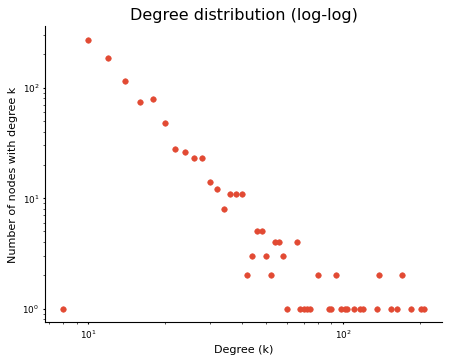

In [20]:
# --- Degree sequence ---
degrees = [d for _, d in G.degree()]

# Count how many nodes have each degree
degree_counts = Counter(degrees)

k = list(degree_counts.keys())
Nk = list(degree_counts.values())

# --- Log-log plot ---
plt.figure()
plt.scatter(k, Nk)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree (k)")
plt.ylabel("Number of nodes with degree k")
plt.title("Degree distribution (log-log)")

plt.show()

In [ ]:
edges = pd.read_csv("experiments_recsys/BA_F_0/cl6_network.csv", header=None, names=['source', 'target'], dtype=str)

# assume columns like: source, target with usernames
print(edges.head())

# Optim: Use pandas to read edge list, it's faster than nx.read_edgelist for large files
df_edges = pd.read_csv(, header=None, names=['u', 'v'])
df_edges[['source', 'target']] = np.sort(df_edges[['u', 'v']], axis=1)
df_edges = df_edges.drop_duplicates()
# Compute degrees from edge list directly
deg_counts = pd.concat([df_edges['source'], df_edges['target']]).value_counts()
author_degrees = deg_counts.to_dict()


In [21]:
nx.density(G)

0.00995995995995996

In [22]:
recommendations["id"] = recommendations["id"].astype(int)
degree_df["user_id"] = degree_df["user_id"].astype(int)

In [23]:
df = recommendations.merge(degree_df, left_on="user_id", right_on="user_id", how="left", suffixes=('_rec', '_network'))

In [24]:
df = df[['user_id', 'post_ids_list', 'degree']]

In [25]:
user_tot_recs = df.groupby("user_id").agg(
    post_ids=("post_ids_list", lambda x: [item for sublist in x for item in sublist]),  # flatten lists across all rounds for a given user_id
    degree=("degree", lambda x: int(round(x.mean())))  # average degree as int == the degree of the user which is static
).reset_index()

user_tot_recs.head()

,user_id,post_ids,degree
0,2,"[1014, 1013, 956, 873, 872, 856, 1047, 1046, 1...",92
1,3,"[2003, 2002, 1990, 1989, 1988, 1904, 2005, 200...",68
2,4,"[349, 180, 179, 178, 128, 96, 528, 527, 526, 5...",29
3,5,"[714, 605, 604, 603, 955, 954, 953, 952, 8116,...",4
4,6,"[2472, 2471, 2470, 2317, 2185, 2184, 2496, 249...",47


In [26]:
user_tot_recs['tot_recs'] = user_tot_recs['post_ids'].apply(len)
user_tot_recs.head()

,user_id,post_ids,degree,tot_recs
0,2,"[1014, 1013, 956, 873, 872, 856, 1047, 1046, 1...",92,100
1,3,"[2003, 2002, 1990, 1989, 1988, 1904, 2005, 200...",68,440
2,4,"[349, 180, 179, 178, 128, 96, 528, 527, 526, 5...",29,2560
3,5,"[714, 605, 604, 603, 955, 954, 953, 952, 8116,...",4,162
4,6,"[2472, 2471, 2470, 2317, 2185, 2184, 2496, 249...",47,180


Text(0, 0.5, 'Number of users')

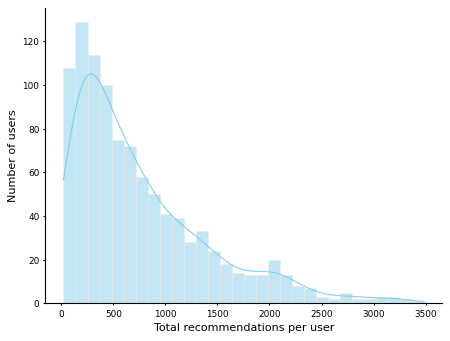

In [27]:
sns.histplot(user_tot_recs['tot_recs'], bins=30, color='skyblue', kde=True)
plt.xlabel('Total recommendations per user')
plt.ylabel('Number of users')

In [28]:
degree_tot_recs = user_tot_recs.groupby("degree").agg(
    avg_recs=("tot_recs", "mean"),
    std_recs = ("tot_recs", "std"),
    count_users=("user_id", "count")
).reset_index()

degree_tot_recs.head()


,degree,avg_recs,std_recs,count_users
0,4,162.000000,NaN,1
1,5,755.819188,656.215779,271
2,6,700.657609,584.568308,184
3,7,756.500000,715.958251,114
4,8,768.689189,653.178717,74


In [29]:
degree_tot_recs = degree_tot_recs.loc[degree_tot_recs['count_users'] >= 0]

In [30]:
degree_tot_recs.head()


,degree,avg_recs,std_recs,count_users
0,4,162.000000,NaN,1
1,5,755.819188,656.215779,271
2,6,700.657609,584.568308,184
3,7,756.500000,715.958251,114
4,8,768.689189,653.178717,74


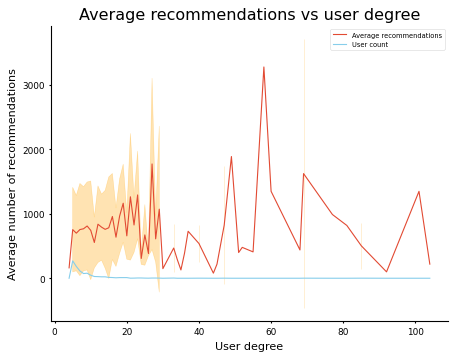

In [31]:
# line with shaded area using seaborn
sns.lineplot(
    data=degree_tot_recs,
    x='degree',
    y='avg_recs',
    label='Average recommendations')

# line with shaded area using seaborn
sns.lineplot(
    data=degree_tot_recs,
    x='degree',
    y='count_users',
    label='User count',
    color='skyblue')

# manually add shaded area for ± std
plt.fill_between(
    degree_tot_recs['degree'],
    degree_tot_recs['avg_recs'] - degree_tot_recs['std_recs'],
    degree_tot_recs['avg_recs'] + degree_tot_recs['std_recs'],
    color='orange',
    alpha=0.3,
)

plt.xlabel("User degree")
plt.ylabel("Average number of recommendations")
plt.title("Average recommendations vs user degree")
plt.legend()
plt.show()


In [32]:
user_uniq_recs = df.groupby("user_id").agg(
    post_ids=("post_ids_list", lambda x: [item for sublist in x for item in sublist]),  # flatten lists across all rounds for a given user_id
    degree=("degree", lambda x: int(round(x.mean())))  # average degree as int == the degree of the user which is static
).reset_index()

user_uniq_recs['tot_uniq_recs'] = user_uniq_recs['post_ids'].apply(lambda x: len(set(x)))  # count unique recommendations

user_uniq_recs.head()

,user_id,post_ids,degree,tot_uniq_recs
0,2,"[1014, 1013, 956, 873, 872, 856, 1047, 1046, 1...",92,74
1,3,"[2003, 2002, 1990, 1989, 1988, 1904, 2005, 200...",68,210
2,4,"[349, 180, 179, 178, 128, 96, 528, 527, 526, 5...",29,566
3,5,"[714, 605, 604, 603, 955, 954, 953, 952, 8116,...",4,91
4,6,"[2472, 2471, 2470, 2317, 2185, 2184, 2496, 249...",47,97


Text(0, 0.5, 'Number of users')

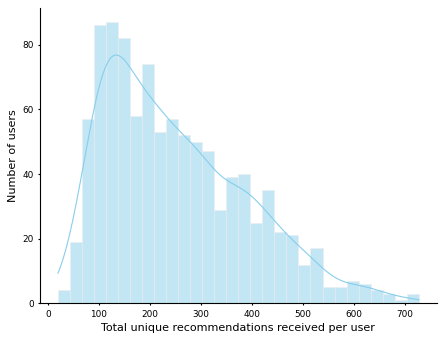

In [33]:
sns.histplot(user_uniq_recs['tot_uniq_recs'], bins=30, color='skyblue', kde=True)
plt.xlabel('Total unique recommendations received per user')
plt.ylabel('Number of users')

In [34]:
degree_uniq_recs = user_uniq_recs.groupby("degree").agg(
    avg_recs=("tot_uniq_recs", "mean"),
    std_recs = ("tot_uniq_recs", "std"),
    count_users=("user_id", "count")
).reset_index()

degree_uniq_recs.head()


,degree,avg_recs,std_recs,count_users
0,4,91.000000,NaN,1
1,5,239.081181,129.316926,271
2,6,233.538043,126.856955,184
3,7,249.377193,139.396321,114
4,8,262.756757,142.990737,74


In [35]:
degree_uniq_recs = degree_uniq_recs.loc[degree_uniq_recs['count_users'] >= 0]

In [36]:
degree_uniq_recs.head()


,degree,avg_recs,std_recs,count_users
0,4,91.000000,NaN,1
1,5,239.081181,129.316926,271
2,6,233.538043,126.856955,184
3,7,249.377193,139.396321,114
4,8,262.756757,142.990737,74


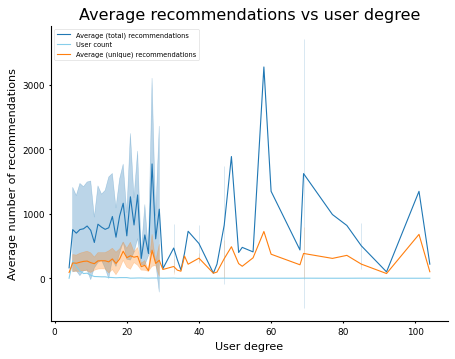

In [37]:
# line with shaded area using seaborn
sns.lineplot(
    data=degree_tot_recs,
    x='degree',
    y='avg_recs',
    label='Average (total) recommendations',
    color='tab:blue',
    errorbar=None
)

# line with shaded area using seaborn
sns.lineplot(
    data=degree_tot_recs,
    x='degree',
    y='count_users',
    label='User count',
    color='skyblue',
    errorbar=None
)

# manually add shaded area for ± std
plt.fill_between(
    degree_tot_recs['degree'],
    degree_tot_recs['avg_recs'] - degree_tot_recs['std_recs'],
    degree_tot_recs['avg_recs'] + degree_tot_recs['std_recs'],
    color='tab:blue',
    alpha=0.3,
)

# line with shaded area using seaborn
sns.lineplot(
    data=degree_uniq_recs,
    x='degree',
    y='avg_recs',
    label='Average (unique) recommendations',
    color = 'tab:orange',
    errorbar=None
)
# manually add shaded area for ± std
plt.fill_between(
    degree_uniq_recs['degree'],
    degree_uniq_recs['avg_recs'] - degree_uniq_recs['std_recs'],
    degree_uniq_recs['avg_recs'] + degree_uniq_recs['std_recs'],
    color = 'tab:orange',
    alpha=0.3,
)

plt.xlabel("User degree")
plt.ylabel("Average number of recommendations")
plt.title("Average recommendations vs user degree")
plt.legend()
plt.show()


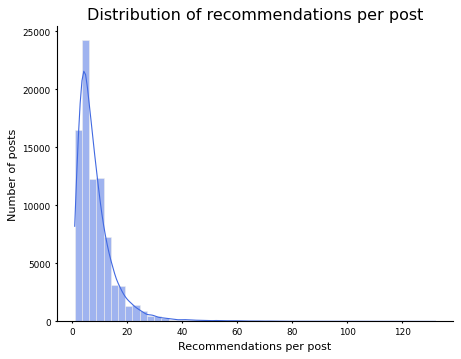

In [38]:
# Each row: a user in a round, with list of post_ids recommended
all_post_ids = [p for sublist in df['post_ids_list'] for p in sublist]

# Count how many times each post was recommended
post_counts = list(Counter(all_post_ids).values())

fig, ax = plt.subplots()
sns.histplot(post_counts, bins=50, kde=True, color='royalblue', ax = ax)
plt.xlabel('Recommendations per post')
plt.ylabel('Number of posts')
plt.title('Distribution of recommendations per post')
plt.show()


In [39]:
recommendations

,id,user_id,post_ids,round,post_ids_list
0,1,831,1,1,[1]
1,2,61,2|1,1,"[2, 1]"
2,3,61,2|1,1,"[2, 1]"
3,4,61,2|1,1,"[2, 1]"
4,5,116,6|5|4|3,1,"[6, 5, 4, 3]"
...,...,...,...,...,...
79180,79181,190,90676|90675|90674|90673|90440|90439|91190|9118...,1440,"[90676, 90675, 90674, 90673, 90440, 90439, 911..."
79181,79182,619,91115|91114|91113|90038|90037|91195|91194|9119...,1440,"[91115, 91114, 91113, 90038, 90037, 91195, 911..."
79182,79183,619,91115|91114|91113|90038|90037|91195|91194|9119...,1440,"[91115, 91114, 91113, 90038, 90037, 91195, 911..."
79183,79184,619,91115|91114|91113|90038|90037|91195|91194|9119...,1440,"[91115, 91114, 91113, 90038, 90037, 91195, 911..."


In [40]:
posts = recommendations.explode('post_ids_list')
posts.head()

,id,user_id,post_ids,round,post_ids_list
0,1,831,1,1,1
1,2,61,2|1,1,2
1,2,61,2|1,1,1
2,3,61,2|1,1,2
2,3,61,2|1,1,1


In [41]:
posts_grouped = posts.groupby('post_ids_list').agg(
    rec_count=('id', 'count'),
    unique_users=('user_id', 'nunique')
).reset_index()

posts_grouped.head()

,post_ids_list,rec_count,unique_users
0,1,5,3
1,2,3,1
2,3,1,1
3,4,1,1
4,5,1,1


<Axes: xlabel='rec_count', ylabel='Count'>

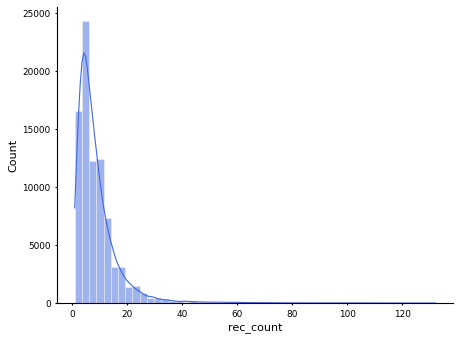

In [42]:
sns.histplot(posts_grouped['rec_count'], bins=50, kde=True, color='royalblue')